# Financial Loan Credit Risk Analysis

## Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [2]:
df = pd.read_csv("finance_loan_credit_risk_dataset.csv")

## Understanding the data

In [3]:
# Displaying the first five rows of the dataset
df.head()

,Loan_ID,Application_Date,Customer_Age,Gender,Marital_Status,Education_Level,Employment_Type,Annual_Income,Credit_Score,Existing_Loans_Count,...,Home_Ownership,Region,Loan_Purpose,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Loan_Status,Repayment_Status
0,LN302366,2024-01-01,40,Male,Single,High School,Business Owner,54396.58,669.0,0,...,Own,Europe,Business,25136.64,60,9.02,522.04,11.52,Approved,On-Time
1,LN302974,2024-01-01,25,Other,Divorced,High School,Self-Employed,87338.50,683.0,0,...,Mortgage,Europe,Auto,11092.49,24,8.23,502.85,6.91,Approved,On-Time
2,LN304565,2024-01-01,44,Female,Married,Master's,Salaried,76136.67,621.0,3,...,Mortgage,Africa,Home,142834.28,24,8.88,6517.49,95.00,Rejected,NaN
3,LN300728,2024-01-01,21,Male,Single,Bachelor's,Salaried,52982.21,NaN,1,...,Own,Europe,Business,72972.66,120,9.66,950.65,23.76,Approved,On-Time
4,LN303105,2024-01-01,46,Male,Single,Master's,Salaried,61433.04,823.0,0,...,Mortgage,South America,Personal,9613.33,60,4.46,179.05,3.50,Approved,On-Time


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               7000 non-null   object 
 1   Application_Date      7000 non-null   object 
 2   Customer_Age          7000 non-null   int64  
 3   Gender                7000 non-null   object 
 4   Marital_Status        7000 non-null   object 
 5   Education_Level       7000 non-null   object 
 6   Employment_Type       7000 non-null   object 
 7   Annual_Income         6803 non-null   float64
 8   Credit_Score          6874 non-null   float64
 9   Existing_Loans_Count  7000 non-null   int64  
 10  Number_of_Dependents  7000 non-null   int64  
 11  Home_Ownership        7000 non-null   object 
 12  Region                7000 non-null   object 
 13  Loan_Purpose          7000 non-null   object 
 14  Loan_Amount           7000 non-null   float64
 15  Loan_Term_Months     

## Displaying the summary statistics (mean, median, std, etc.) for numerical columns

In [5]:
df.describe()

,Customer_Age,Annual_Income,Credit_Score,Existing_Loans_Count,Number_of_Dependents,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio
count,7000.000000,6803.000000,6874.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000
mean,38.074429,45464.524156,676.399767,1.394714,1.513286,54447.838710,62.838857,8.348157,1741.03218,43.127131
std,10.345263,26109.730404,78.601189,1.316388,1.371373,67982.997488,51.349134,1.972031,2959.21335,33.836593
min,21.000000,8000.000000,346.000000,0.000000,0.000000,944.300000,12.000000,2.500000,14.11000,1.000000
25%,30.000000,27505.905000,626.000000,0.000000,0.000000,10941.630000,36.000000,6.980000,248.33500,13.777500
50%,38.000000,40766.900000,678.000000,1.000000,1.000000,20603.590000,48.000000,8.320000,589.15500,30.400000
75%,45.000000,58101.415000,730.000000,2.000000,2.000000,81874.270000,84.000000,9.610000,1880.28500,79.350000
max,70.000000,232856.200000,850.000000,5.000000,5.000000,389391.710000,240.000000,16.910000,27581.67000,95.000000


## Checking for null values

In [6]:
df.isnull().mean()*100

Loan_ID                  0.000000
Application_Date         0.000000
Customer_Age             0.000000
Gender                   0.000000
Marital_Status           0.000000
Education_Level          0.000000
Employment_Type          0.000000
Annual_Income            2.814286
Credit_Score             1.800000
Existing_Loans_Count     0.000000
Number_of_Dependents     0.000000
Home_Ownership           0.000000
Region                   0.000000
Loan_Purpose             0.000000
Loan_Amount              0.000000
Loan_Term_Months         0.000000
Interest_Rate            0.000000
Monthly_Installment      0.000000
Debt_to_Income_Ratio     0.000000
Loan_Status              0.000000
Repayment_Status        21.642857
dtype: float64

## Handling the null values

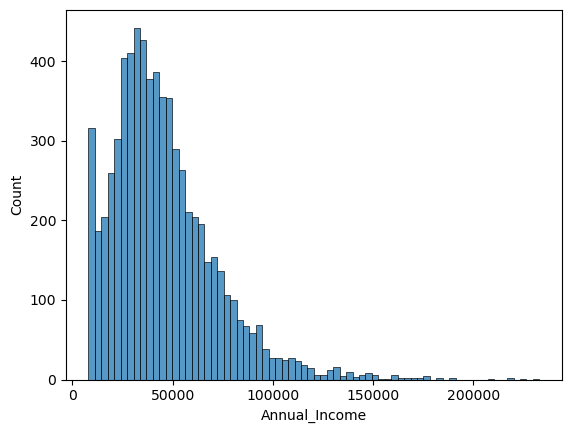

In [7]:
# Checking the distribution of annual income column
sns.histplot(df["Annual_Income"])
plt.show()

In [8]:
# Replacing the null values with the median of that column
df["Annual_Income"] = df["Annual_Income"].fillna(df["Annual_Income"].median())

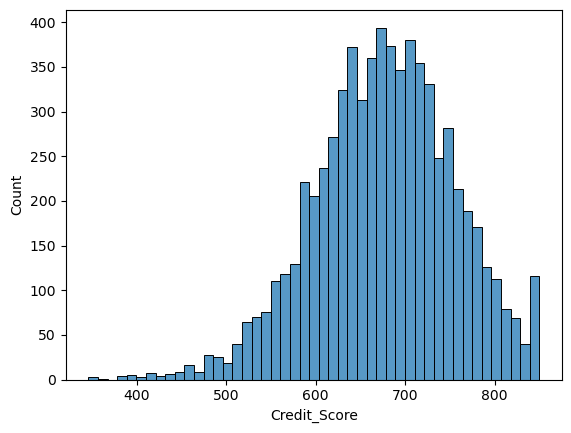

In [9]:
# Checking the distribution of credit score column
sns.histplot(df["Credit_Score"])
plt.show()

In [10]:
# Replacing the null values with the median of that column
df["Credit_Score"] = df["Credit_Score"].fillna(df["Credit_Score"].median())

In [11]:
# Understanding the rows with null values in repayment status column
df[df["Repayment_Status"].isna()]

,Loan_ID,Application_Date,Customer_Age,Gender,Marital_Status,Education_Level,Employment_Type,Annual_Income,Credit_Score,Existing_Loans_Count,...,Home_Ownership,Region,Loan_Purpose,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Loan_Status,Repayment_Status
2,LN304565,2024-01-01,44,Female,Married,Master's,Salaried,76136.67,621.0,3,...,Mortgage,Africa,Home,142834.28,24,8.88,6517.49,95.00,Rejected,NaN
11,LN302832,2024-01-02,23,Female,Divorced,Master's,Unemployed,13899.15,624.0,4,...,Mortgage,North America,Personal,6150.78,24,8.93,280.80,63.03,Rejected,NaN
14,LN306129,2024-01-02,40,Male,Married,Master's,Unemployed,10419.59,468.0,2,...,Own,Asia,Auto,24067.51,36,12.70,807.46,95.00,Rejected,NaN
15,LN304195,2024-01-02,32,Female,Single,High School,Unemployed,8000.00,636.0,5,...,Mortgage,Europe,Personal,13442.03,24,10.01,620.34,95.00,Rejected,NaN
28,LN300076,2024-01-04,34,Female,Widowed,Master's,Self-Employed,51194.15,706.0,5,...,Mortgage,Australia,Business,98423.55,24,9.24,4507.30,95.00,Pending,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6978,LN301043,2025-12-30,21,Female,Single,PhD,Unemployed,20930.48,587.0,1,...,Rent,South America,Personal,8515.37,24,10.60,395.30,34.88,Pending,NaN
6990,LN305210,2025-12-31,30,Female,Married,Bachelor's,Salaried,44263.44,615.0,0,...,Rent,South America,Home,196032.51,36,8.94,6228.31,95.00,Pending,NaN
6991,LN302753,2025-12-31,27,Male,Single,Bachelor's,Unemployed,18131.95,558.0,0,...,Mortgage,North America,Education,11616.10,12,8.93,1015.47,67.21,Rejected,NaN
6996,LN303121,2025-12-31,41,Female,Divorced,Bachelor's,Business Owner,39531.23,659.0,0,...,Rent,Africa,Home,136738.83,48,8.57,3374.90,95.00,Pending,NaN


In [12]:
# Checking the values of loan status for the rows with null values in repayment status
df[df["Repayment_Status"].isna()][["Loan_Status"]].value_counts()

Loan_Status
Pending        1049
Rejected        466
Name: count, dtype: int64

In [13]:
# Replacing the null values with "Not_Issued"
df["Repayment_Status"] = df["Repayment_Status"].fillna("Not Issued")

In [14]:
# Changing the data type of the application date column
df["Application_Date"] = pd.to_datetime(df["Application_Date"])

# Exploratory Data Analysis (EDA)

# The default rate across different credit score ranges

In [15]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a column named Credit Score Range based on credit scores
approved_data.loc[:,"Credit_Score_Range"] = "Below 570"
approved_data.loc[approved_data["Credit_Score"] >= 570,"Credit_Score_Range"] = "570-669"
approved_data.loc[approved_data["Credit_Score"] >= 670,"Credit_Score_Range"] = "670-769"
approved_data.loc[approved_data["Credit_Score"] >= 770,"Credit_Score_Range"] = "Above 769"

# Calculating total number of approved loans and default loan rate across different credit score ranges
final_data = approved_data.groupby("Credit_Score_Range").agg(total_approved_loans=("Loan_ID", "count"),
                                                            default_payment_rate = ("Repayment_Status", lambda x: (x == "Defaulted").mean()*100)).round(2)

# Sorting and displaying the data
final_data.sort_values(by = "default_payment_rate", ascending = False)

,total_approved_loans,default_payment_rate
Credit_Score_Range,,
Below 570,173,15.61
570-669,1783,13.57
670-769,2754,6.61
Above 769,775,1.55


# The average DTI for each type of repayment behaviour

In [16]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Calculating average DTI for each type of repayment behaviour
repayment_data = approved_data.groupby("Repayment_Status").agg(avg_DTI=("Debt_to_Income_Ratio","mean")).round(2)

# Displaying the data
repayment_data

,avg_DTI
Repayment_Status,
Defaulted,54.52
Late Payments,31.94
On-Time,31.82


# Total number of applicants, average monthly installment, default rate and percentage of preference across different loan terms

In [17]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Calculating total number of applications, average monthly installment, default rate and percentage of preference across different loan terms
term_data = approved_data.groupby("Loan_Term_Months").agg(total_applicants=("Loan_ID","count"),
                                                          avg_monthly_installment=("Monthly_Installment","mean"),
                                                          default_rate = ("Repayment_Status", lambda x: (x=="Defaulted").mean()*100)).reset_index()

# Calculating percentage of number of applicants for each loan term
total_applicants = approved_data["Loan_ID"].count()
term_data["preference_pct"] = (term_data["total_applicants"]/total_applicants) * 100

# Sorting and displaying the data
term_data.round(2).sort_values(by="Loan_Term_Months")

,Loan_Term_Months,total_applicants,avg_monthly_installment,default_rate,preference_pct
0,12,483,4355.77,12.84,8.81
1,24,730,2054.03,10.82,13.31
2,36,975,1345.01,7.49,17.78
3,48,831,1069.59,7.70,15.15
4,60,929,845.48,7.43,16.94
5,84,569,667.84,7.73,10.37
6,120,474,601.90,7.38,8.64
7,180,311,426.89,6.11,5.67
8,240,183,372.89,9.84,3.34


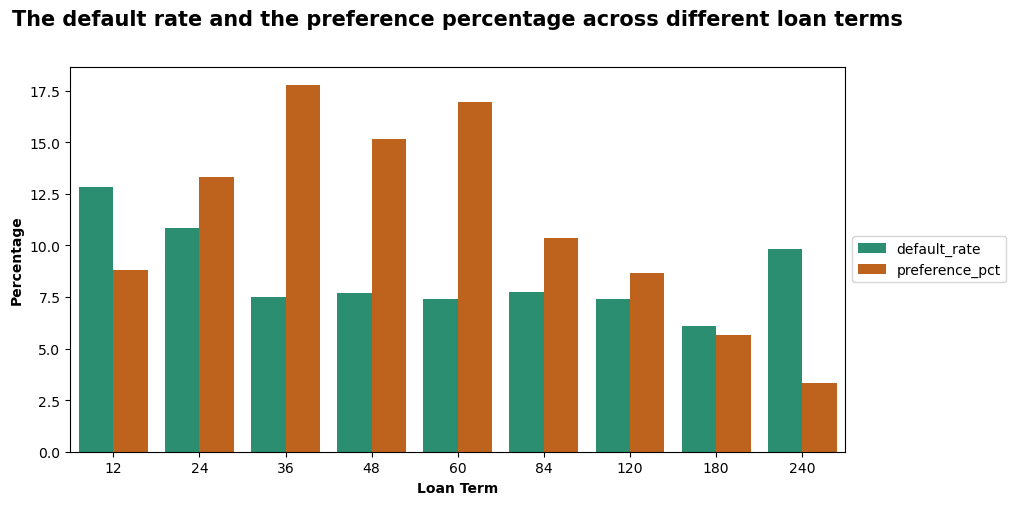

In [18]:
## formatting the data for plotting the graph
term_melted_data = term_data.melt(id_vars="Loan_Term_Months", value_vars=["default_rate","preference_pct"], var_name="variables", value_name="pct_value")

## Plotting the bar chart depicting the default rate and the preference percentage across different loan terms
plt.figure(figsize=(10,5))
sns.barplot(data = term_melted_data, x = "Loan_Term_Months", y = "pct_value", hue = "variables", palette="Dark2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("The default rate and the preference percentage across different loan terms", fontweight="bold", fontsize=15, pad=30)
plt.xlabel("Loan Term", fontweight = "bold")
plt.ylabel("Percentage", fontweight = "bold")
plt.show()

# Interest Rate vs Profitability

In [19]:
# Creating a int_tier column based on interest rate
df["int_tier"] = "Low"
df.loc[df["Interest_Rate"] >= 8, "int_tier"] = "Medium"
df.loc[df["Interest_Rate"] >= 12, "int_tier"] = "High"
df.loc[df["Interest_Rate"] >= 16, "int_tier"] = "Very High"

# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a profit column according to the repayment status
approved_data.loc[approved_data["Repayment_Status"].isin(["On-Time","Late Payments"]), "profit"] = (approved_data["Monthly_Installment"] * approved_data["Loan_Term_Months"]) - approved_data["Loan_Amount"]
approved_data.loc[approved_data["Repayment_Status"] == "Defaulted", "profit"] = - approved_data["Loan_Amount"]

# Calculating total loan amount and total profit across different interest tiers
int_data = approved_data.groupby("int_tier").agg(total_loan_amount=("Loan_Amount","sum"),
                                                  total_profit=("profit","sum")).reset_index()

# Adding a profitability column
int_data["profitability"] = round((int_data["total_profit"] / int_data["total_loan_amount"]) * 100, 2)

# Displaying the data
int_data

,int_tier,total_loan_amount,total_profit,profitability
0,High,1.277221e+06,456633.91,35.75
1,Low,1.435844e+08,10191383.75,7.10
2,Medium,1.016413e+08,6747149.46,6.64


In [20]:
# Displaying the distribtion of high interest rates across different loan statuses
data = df[df["int_tier"].isin(["Very High","High"])]["Loan_Status"].value_counts()
data

Loan_Status
Rejected    117
Pending      89
Approved     52
Name: count, dtype: int64

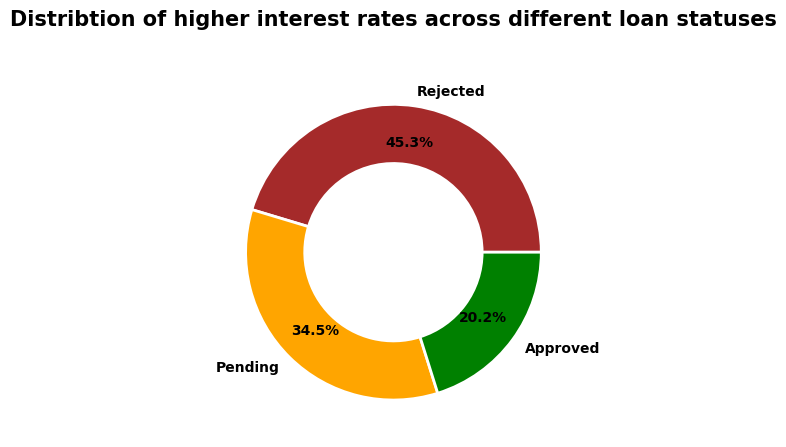

In [21]:
# Plotting pie chart for showing the distribtion of higher interest rates across different loan statuses
plt.pie(data, labels=data.index, autopct="%1.1f%%", colors=["brown","orange","green"], pctdistance = 0.75, 
        wedgeprops=dict(width=0.4, edgecolor = "white", linewidth = 2),textprops={"weight":"bold", "fontsize": 10})
plt.title("Distribtion of higher interest rates across different loan statuses", fontweight = "bold", fontsize = 15, pad = 30)
plt.show()

# The average interest rate, monthly installment, credit score, DTI and income by loan status

In [22]:
# Calculating average interest rate, monthly installment, credit score, DTI and income for each type of loan status
loan_status_data = df.groupby("Loan_Status").agg(avg_int_rate=("Interest_Rate","mean"),
                                     avg_monthly_installment=("Monthly_Installment","mean"),
                                     avg_credit_score=("Credit_Score","mean"),
                                     avg_DTI = ("Debt_to_Income_Ratio","mean"),
                                     avg_income = ("Annual_Income","mean")).round(2)

# Displaying the data
loan_status_data

,avg_int_rate,avg_monthly_installment,avg_credit_score,avg_DTI,avg_income
Loan_Status,,,,,
Approved,7.98,1359.21,694.22,33.76,49721.24
Pending,9.19,3146.14,634.11,72.74,34003.12
Rejected,10.82,3072.29,562.24,86.75,19175.95


# Interest revenue across different loan purposes

In [23]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Generating a column for interest revenue
approved_data["int_rev"] = ((approved_data["Monthly_Installment"] * approved_data["Loan_Term_Months"]) - approved_data["Loan_Amount"]).round(2)

# Calculating total interest revenue across different loan purposes
int_rev_data = approved_data.groupby("Loan_Purpose").agg(total_int_rev = ("int_rev", "sum")).reset_index()

# Sorting and displaying the data
int_rev_data.sort_values(by="total_int_rev", ascending = False)

,Loan_Purpose,total_int_rev
4,Home,29337837.41
1,Business,13510673.24
0,Auto,5723026.96
6,Personal,3387819.94
3,Education,2889566.66
2,Debt Consolidation,2487261.20
5,Medical,824450.99


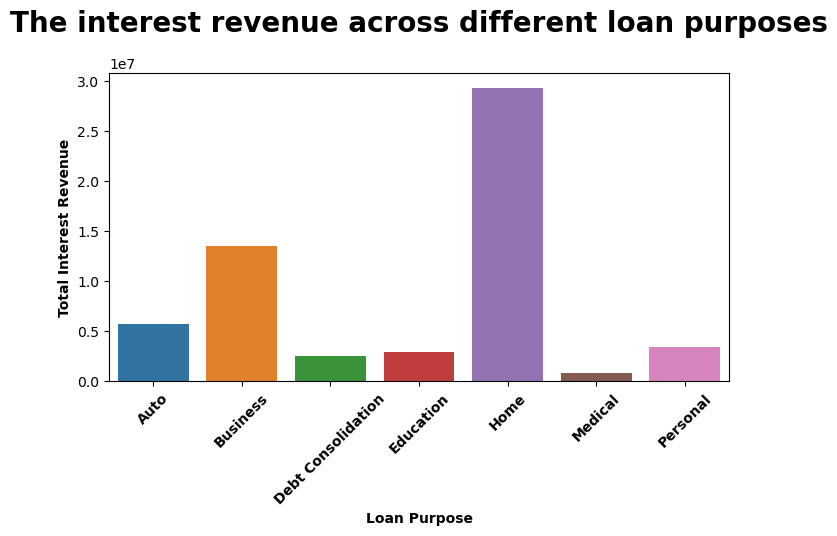

In [24]:
## Creating a bar chart depicting the interest revenue across different loan purposes
plt.figure(figsize=(8,4))
sns.barplot(int_rev_data,x="Loan_Purpose",y="total_int_rev",hue="Loan_Purpose", legend = False)
plt.title("The interest revenue across different loan purposes", fontweight = "bold", fontsize = 20, pad = 30)
plt.xlabel("Loan Purpose", fontweight = "bold")
plt.ylabel("Total Interest Revenue", fontweight = "bold")
plt.xticks(rotation=45, fontweight = "bold")
plt.show()

# The rates of different repayment statuses across different loan purposes

In [25]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Calculating rates of different repayment statuses across different loan purposes
purpose_data = approved_data.groupby("Loan_Purpose").agg(Default_Rate_pct=("Repayment_Status",lambda x: (x == "Defaulted").mean()*100),
                                                         Late_Payment_Rate_pct=("Repayment_Status",lambda x:(x == "Late Payments").mean()*100),
                                                         On_Time_Rate_pct=("Repayment_Status",lambda x:(x == "On-Time").mean()*100)
                                                        ).round(2).sort_values(by = "Default_Rate_pct", ascending = False)

## Displaying the data
purpose_data

,Default_Rate_pct,Late_Payment_Rate_pct,On_Time_Rate_pct
Loan_Purpose,,,
Home,15.49,17.44,67.07
Business,13.32,17.17,69.50
Auto,6.60,18.68,74.72
Debt Consolidation,6.54,19.63,73.83
Education,6.48,16.94,76.58
Personal,6.06,19.90,74.04
Medical,5.32,15.32,79.36


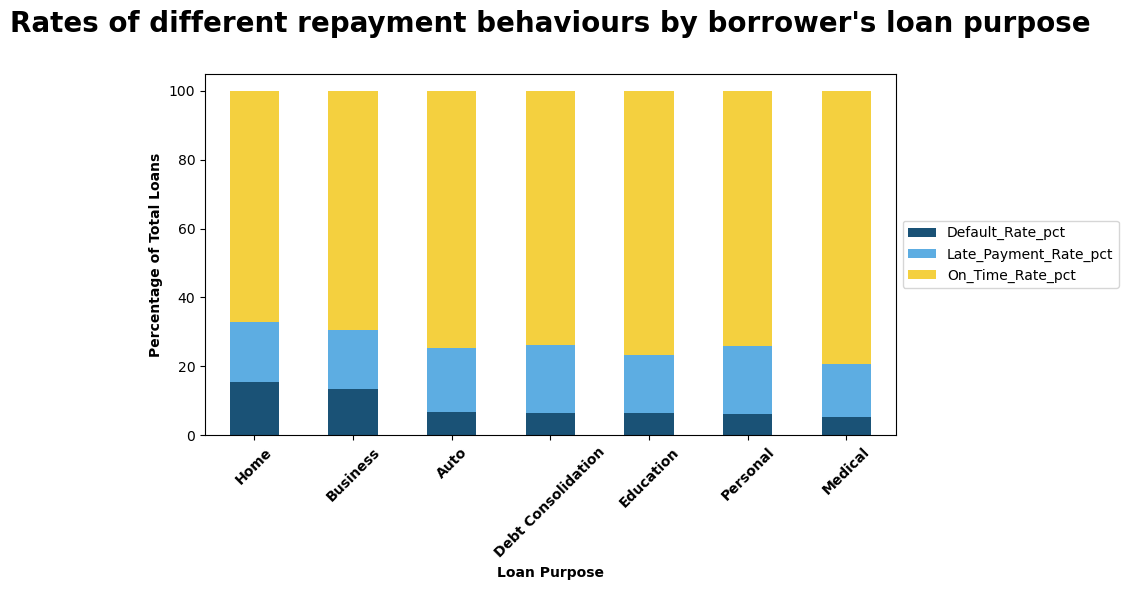

In [26]:
# Plotting the stacked bar chart depicting rates of different repayment statuses for each loan purpose
purpose_data.plot(kind = "bar", stacked = True, color=["#1A5276","#5DADE2","#F4D03F"], figsize=(10,6))
plt.legend(title="Repayment_Status")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Rates of different repayment behaviours by borrower's loan purpose", fontweight="bold", fontsize = 20, pad = 30)
plt.xlabel("Loan Purpose", fontweight="bold")
plt.ylabel("Percentage of Total Loans", fontweight="bold")
plt.xticks(rotation=45, fontweight="bold")
plt.tight_layout()
plt.show()

# Relationship between the number of existing loans and the final loan status

In [27]:
# Calculating the rates of different loan categories across different numbers of existing loans
final_status_data = df.groupby("Existing_Loans_Count").agg(approved_loan_rate=("Loan_Status", lambda x: (x=="Approved").mean() *100),
                                      pending_loan_rate=("Loan_Status", lambda x: (x=="Pending").mean() *100),
                                      rejected_loan_rate=("Loan_Status", lambda x: (x=="Rejected").mean() *100)).round(2)

# Displaying the data
final_status_data

,approved_loan_rate,pending_loan_rate,rejected_loan_rate
Existing_Loans_Count,,,
0,81.32,13.76,4.92
1,80.27,12.92,6.82
2,76.69,15.97,7.34
3,73.26,18.63,8.10
4,73.32,17.55,9.13
5,68.67,22.67,8.67


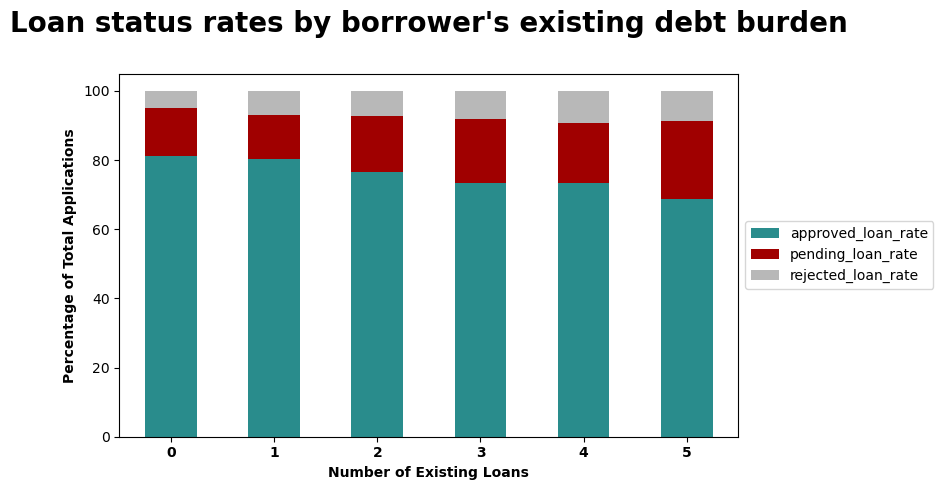

In [28]:
# Plotting the stacked bar chart showing the rates of different loan categories across different numbers of existing loans
final_status_data.plot(kind = "bar", stacked = True, color=["#298C8C","#A00000","#B8B8B8"], figsize=(9,5))
plt.legend(title = "Loan_Status")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Loan status rates by borrower's existing debt burden", fontweight="bold", fontsize=20, pad=30)
plt.xlabel("Number of Existing Loans", fontweight="bold")
plt.ylabel("Percentage of Total Applications", fontweight="bold")
plt.xticks(rotation=0, fontweight="bold")
plt.tight_layout() 
plt.show()

# Relationship between the number of existing loans and the repayment status

In [29]:
# Filtering the original data for issued loans
df1 = df[df["Repayment_Status"] != "Not Issued"]

# Calculating the rates of different repayment behaviour categories across different numbers of existing loans
repayment_status_data = df1.groupby("Existing_Loans_Count").agg(default_payment_rate=("Repayment_Status", lambda x: (x=="Defaulted").mean() *100),
                                      late_payment_rate=("Repayment_Status", lambda x: (x=="Late Payments").mean() *100),
                                      on_time_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean() *100)).round(2)

# Displaying the data
repayment_status_data

,default_payment_rate,late_payment_rate,on_time_payment_rate
Existing_Loans_Count,,,
0,6.99,19.53,73.47
1,7.60,17.75,74.65
2,10.04,17.19,72.77
3,11.22,16.90,71.88
4,10.16,17.05,72.79
5,7.77,23.30,68.93


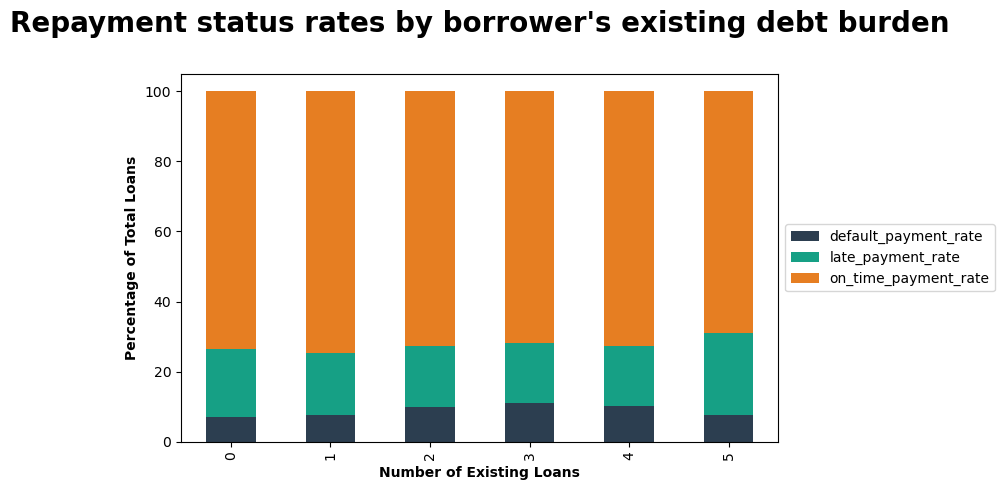

In [30]:
# Plotting the stacked bar chart showing the rates of different repayment behaviour categories across different numbers of existing loans
repayment_status_data.plot(kind = "bar", stacked = True, color=["#2C3E50","#16A085","#E67E22"],figsize=(9,5))
plt.legend(title="Repayment_Status")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Repayment status rates by borrower's existing debt burden", fontweight="bold", fontsize=20, pad=30)
plt.xlabel("Number of Existing Loans", fontweight="bold")
plt.ylabel("Percentage of Total Loans", fontweight="bold")
plt.tight_layout()
plt.show()

# The default rate across different employment type

In [31]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Calculating total approved loans, total defaulted loans, default rate across different employment types
emp_data = approved_data.groupby("Employment_Type").agg(total_approved_loans = ("Loan_ID","count"),
                                                        defaulted_loans = ("Repayment_Status", lambda x: (x == "Defaulted").sum()),
                                                        default_rate = ("Repayment_Status", lambda x: (x == "Defaulted").mean()*100)).reset_index()

# Sorting and displaying the data
emp_data.round(2).sort_values(by = "default_rate", ascending =False)   

,Employment_Type,total_approved_loans,defaulted_loans,default_rate
3,Unemployed,84,20,23.81
1,Salaried,3364,298,8.86
0,Business Owner,815,58,7.12
2,Self-Employed,1222,87,7.12


In [32]:
# Calculating rates of approved, pending, rejected loans across different employment types
df.groupby("Employment_Type").agg(approved_loan_rate=("Loan_Status",lambda x: (x=="Approved").mean()*100),
                                  pending_loan_rate=("Loan_Status",lambda x: (x=="Pending").mean()*100),
                                  rejected_loan_rate=("Loan_Status",lambda x: (x=="Rejected").mean()*100))

,approved_loan_rate,pending_loan_rate,rejected_loan_rate
Employment_Type,,,
Business Owner,85.073069,12.943633,1.983299
Salaried,83.267327,14.108911,2.623762
Self-Employed,84.920083,12.369701,2.710215
Unemployed,14.920071,31.438721,53.641208


# Effect of home ownership status on repayment behavior

In [33]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a bad loan column
approved_data["bad_loan"] = approved_data["Repayment_Status"].isin(["Late Payments","Defaulted"]).astype(int)

# Calculating total issued loans, total bad loans across different home ownership categories
housing_data = approved_data.groupby("Home_Ownership").agg(total_issued_loans=("Loan_ID","count"),
                                                           total_bad_loans=("bad_loan","sum")).reset_index()

# Calculating the rate of bad loans
housing_data["bad_loan_rate_pct"] = (housing_data["total_bad_loans"] / housing_data["total_issued_loans"]) * 100

# Displaying the data
housing_data.round(1)

,Home_Ownership,total_issued_loans,total_bad_loans,bad_loan_rate_pct
0,Mortgage,2031,537,26.4
1,Own,1249,329,26.3
2,Rent,2205,595,27.0


# Rates of different repayment statuses and loan approval by income level, education level, age and gender

In [34]:
# Creating a data containing total number of applications and approval rate for each type of education level
edu_approval_data = df.groupby("Education_Level").agg(total_applications=("Loan_ID","count"),
                              approval_rate=("Loan_Status",lambda x: (x=="Approved").mean()*100)).round(2)

# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a data containing the rates of different repayment statuses for each type of education level
edu_repayment_data = approved_data.groupby("Education_Level").agg(ontime_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean()*100),
                              late_payment_rate=("Repayment_Status", lambda x: (x=="Late Payments").mean()*100),
                              default_payment_rate=("Repayment_Status", lambda x: (x=="Defaulted").mean()*100)).round(2)

# Merging these two data
edu_data = edu_approval_data.merge(edu_repayment_data, on = "Education_Level")
edu_data["bad_loan_rate"] = edu_data["late_payment_rate"] + edu_data["default_payment_rate"]

# Displaying the data
edu_data

,total_applications,approval_rate,ontime_payment_rate,late_payment_rate,default_payment_rate,bad_loan_rate
Education_Level,,,,,,
Bachelor's,2923,78.96,72.05,19.11,8.84,27.95
High School,1927,74.36,73.41,17.10,9.49,26.59
Master's,1790,80.61,74.15,18.09,7.76,25.85
PhD,360,83.61,79.40,16.94,3.65,20.59


In [35]:
# Creating income group column
df["Income_Group"] = "Low(<40k)"
df.loc[df["Annual_Income"] > 41000, "Income_Group"] = "Medium(41k - 80k)"
df.loc[df["Annual_Income"] > 81000, "Income_Group"] = "High(81k - 150k)"
df.loc[df["Annual_Income"] > 151000, "Income_Group"] = "Very High(>151k)"

# Creating a data containing total number of applications, total number of approved loans and approval rate for each income group
income_approval_data = df.groupby("Income_Group").agg(total_applications=("Loan_ID","count"),
                                                      approved_loan=("Loan_Status",lambda x: (x=="Approved").sum()),
                                                      approval_rate=("Loan_Status",lambda x: (x=="Approved").mean()*100)).round(2)

# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a data containing the rates of different repayment statuses for each income group
income_repayment_data = approved_data.groupby("Income_Group").agg(ontime_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean()*100),
                              late_payment_rate=("Repayment_Status", lambda x: (x=="Late Payments").mean()*100),
                              default_payment_rate=("Repayment_Status", lambda x: (x=="Defaulted").mean()*100)).round(2)

# Creating a bad loan rate column
income_repayment_data["bad_loan_rate"] = income_repayment_data["late_payment_rate"] + income_repayment_data["default_payment_rate"]


# Merging these two data
income_data = income_approval_data.merge(income_repayment_data, on = "Income_Group")

# Displaying the data
income_data

,total_applications,approved_loan,approval_rate,ontime_payment_rate,late_payment_rate,default_payment_rate,bad_loan_rate
Income_Group,,,,,,,
High(81k - 150k),571,537,94.05,78.03,18.06,3.91,21.97
Low(<40k),3624,2447,67.52,71.80,17.00,11.20,28.20
Medium(41k - 80k),2774,2470,89.04,73.81,19.47,6.72,26.19
Very High(>151k),31,31,100.00,80.65,12.90,6.45,19.35


In [36]:
# Creating age group column
df["Age_Group"] = "Under 30"
df.loc[df["Customer_Age"] >= 30, "Age_Group"] = "30-45"
df.loc[df["Customer_Age"] >= 46, "Age_Group"] = "46-60"
df.loc[df["Customer_Age"] >= 61, "Age_Group"] = "Above 60"

# Creating a data containing total number of applications and approval rate for each age group
age_approval_data = df.groupby("Age_Group").agg(total_applications=("Loan_ID","count"),
                              approval_rate=("Loan_Status",lambda x: (x=="Approved").mean()*100)).round(2)

# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a data containing the rates of different repayment statuses for each age group
age_repayment_data = approved_data.groupby("Age_Group").agg(ontime_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean()*100),
                              late_payment_rate=("Repayment_Status", lambda x: (x=="Late Payments").mean()*100),
                              default_payment_rate=("Repayment_Status", lambda x: (x=="Defaulted").mean()*100)).round(2)

# Merging these two data
age_data = age_approval_data.merge(age_repayment_data, on = "Age_Group")

# Adding a bad loan rate column
age_data["bad_loan_rate"] = age_data["late_payment_rate"] + age_data["default_payment_rate"]

# Displaying the data
age_data

,total_applications,approval_rate,ontime_payment_rate,late_payment_rate,default_payment_rate,bad_loan_rate
Age_Group,,,,,,
30-45,3730,77.67,73.49,17.92,8.60,26.52
46-60,1552,79.06,73.11,18.58,8.31,26.89
Above 60,140,81.43,64.04,28.07,7.89,35.96
Under 30,1578,79.02,74.18,17.56,8.26,25.82


In [37]:
# Creating a data containing total number of applications and approval rate for each gender
gender_approval_data = df.groupby("Gender").agg(total_applications=("Loan_ID","count"),
                              approval_rate=("Loan_Status",lambda x: (x=="Approved").mean()*100)).round(2)

# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a data containing the rates of different repayment statuses for each gender
gender_repayment_data = approved_data.groupby("Gender").agg(ontime_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean()*100),
                              late_payment_rate=("Repayment_Status", lambda x: (x=="Late Payments").mean()*100),
                              default_payment_rate=("Repayment_Status", lambda x: (x=="Defaulted").mean()*100)).round(2)

# Merging these two data
gender_data = gender_approval_data.merge(gender_repayment_data, on = "Gender")

# Adding a bad loan rate column
gender_data["bad_loan_rate"] = gender_data["late_payment_rate"] + gender_data["default_payment_rate"]

# Displaying the data
gender_data

,total_applications,approval_rate,ontime_payment_rate,late_payment_rate,default_payment_rate,bad_loan_rate
Gender,,,,,,
Female,3346,78.21,74.17,17.27,8.56,25.83
Male,3533,78.52,72.75,19.14,8.11,27.25
Other,121,77.69,69.15,15.96,14.89,30.85


# Region wise total loan amount and profitability

In [38]:
# Filtering the original data for approved loans
approved_data = df[df["Loan_Status"] == "Approved"].copy()

# Creating a profit column according to the repayment status
approved_data.loc[approved_data["Repayment_Status"].isin(["On-Time","Late Payments"]), "profit"] = (approved_data["Monthly_Installment"] * approved_data["Loan_Term_Months"]) - approved_data["Loan_Amount"]
approved_data.loc[approved_data["Repayment_Status"] == "Defaulted", "profit"] = - approved_data["Loan_Amount"]

# Calculating total loan amount, total profit and ontime_payment_rate across regions
region_data = approved_data.groupby("Region").agg(total_amount=("Loan_Amount","sum"),
                                                  total_profit=("profit","sum"),
                                                  ontime_payment_rate=("Repayment_Status", lambda x: (x=="On-Time").mean() * 100)).reset_index()

# Generating a profitability column
region_data["profitability"] = round((region_data["total_profit"] / region_data["total_amount"]) * 100, 2)

# Sorting and displaying the data
region_data[["Region","total_amount","profitability", "ontime_payment_rate"]].sort_values(by="profitability", ascending = False).round(2)

,Region,total_amount,profitability,ontime_payment_rate
2,Australia,9387711.05,12.05,76.23
1,Asia,55074653.97,9.54,73.93
4,North America,73353890.46,7.85,73.04
5,South America,22957565.04,7.56,72.62
3,Europe,69435175.45,4.17,73.13
0,Africa,16293890.43,3.82,73.24


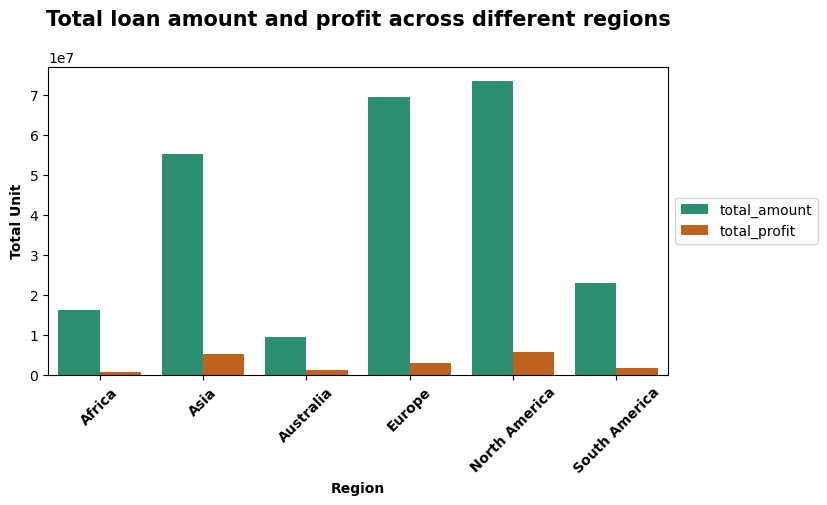

In [39]:
## Formatting the data for plotting the bar chart
region_melted_data = region_data.melt(id_vars="Region", value_vars=["total_amount","total_profit"], var_name="variables", value_name="value")

## Creating a column chart depicting the total loan amount and profit for each region
plt.figure(figsize=(8,4))
sns.barplot(region_melted_data,x="Region",y="value", hue="variables", palette="Dark2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Total loan amount and profit across different regions", fontweight = "bold", fontsize = 15, pad = 30)
plt.xlabel("Region", fontweight = "bold")
plt.ylabel("Total Unit", fontweight = "bold")
plt.xticks(rotation=45, fontweight = "bold")
plt.show()

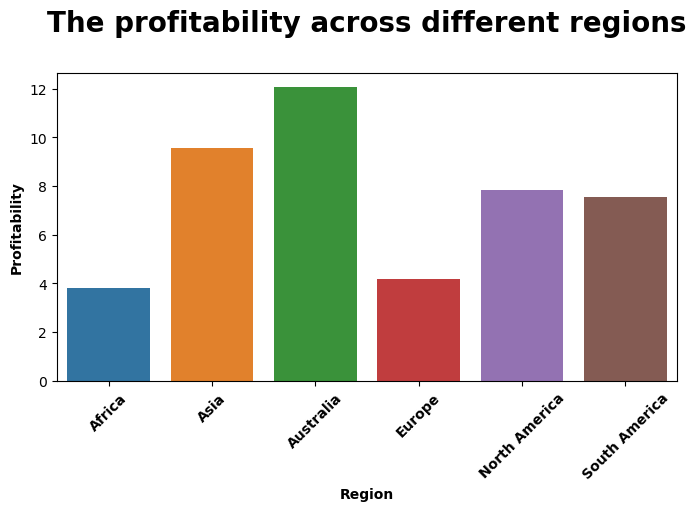

In [40]:
## Creating a column chart depicting the profitability for each region
plt.figure(figsize=(8,4))
sns.barplot(region_data,x ="Region",y="profitability", hue="Region", legend = False)
plt.title("The profitability across different regions", fontweight = "bold", fontsize = 20, pad = 30)
plt.xlabel("Region", fontweight = "bold")
plt.ylabel("Profitability", fontweight = "bold")
plt.xticks(rotation=45, fontweight = "bold")
plt.show()

# Quarterly trends by application date for total number of applications

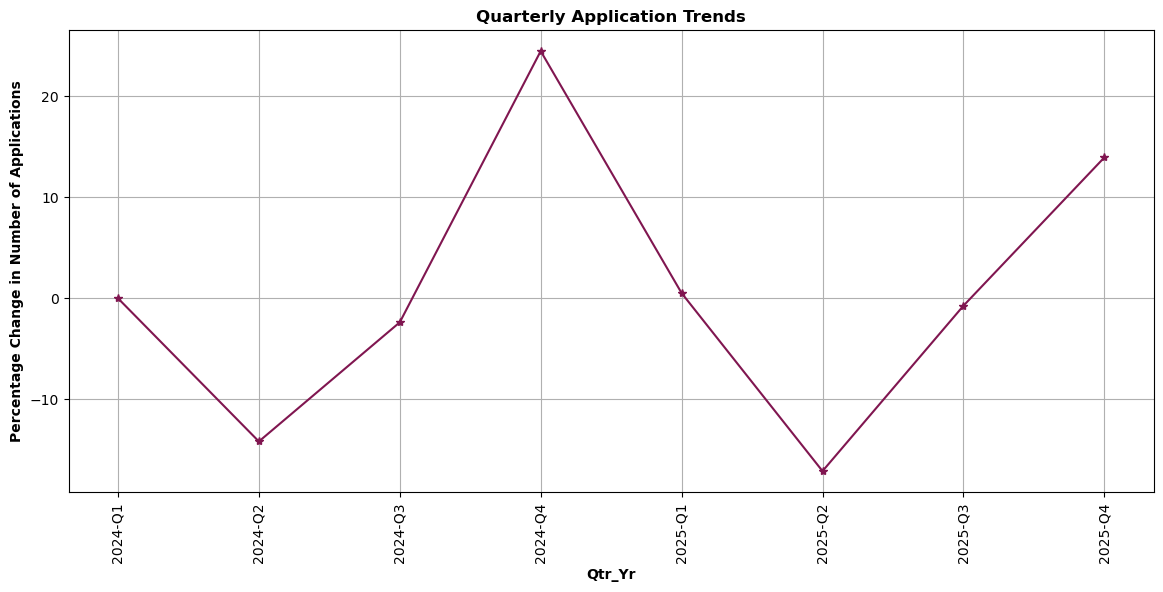

In [41]:
# Creating a data for total number of applications over months
MoM_data = df.groupby(df["Application_Date"].dt.to_period("M")).agg(total_application=("Loan_ID","count")).reset_index()

# Creating month and quater column
MoM_data["m"] = MoM_data["Application_Date"].dt.strftime("%b")
MoM_data.loc[MoM_data["m"].isin(["Jan","Feb","Mar"]),"Qtr"] = "Q1"
MoM_data.loc[MoM_data["m"].isin(["Apr","May","Jun"]),"Qtr"] = "Q2"
MoM_data.loc[MoM_data["m"].isin(["Jul","Aug","Sep"]),"Qtr"] = "Q3"
MoM_data.loc[MoM_data["m"].isin(["Oct","Nov","Dec"]),"Qtr"] = "Q4"

# Creating a qtr_yr column
MoM_data["yr"] = MoM_data["Application_Date"].dt.year.astype("str")
MoM_data["Qtr_Yr"] = MoM_data["yr"] +"-"+ MoM_data["Qtr"]

# Creating the required data containing total number of applications in each quater
qtr_data = MoM_data.merge(MoM_data.groupby("Qtr_Yr",as_index=False).agg(total_app=("total_application","sum")), on="Qtr_Yr")
final_data = qtr_data[["yr","Qtr_Yr","total_app"]].drop_duplicates()

# Calculating the percentage of quarterly fluctuations in the number of applications
final_data["MoM_fluctuation_(%)"] = final_data["total_app"].pct_change()*100
final_data["MoM_fluctuation_(%)"] = final_data["MoM_fluctuation_(%)"].fillna(0)

# Plotting the line chart depicting the trend of quarterly applications
plt.figure(figsize=(14,6))
plt.plot(final_data["Qtr_Yr"],final_data["MoM_fluctuation_(%)"], marker = "*", color = "#801650")
plt.title("Quarterly Application Trends", fontweight="bold")
plt.xlabel("Qtr_Yr", fontweight="bold")
plt.ylabel("Percentage Change in Number of Applications", fontweight="bold")
plt.xticks(rotation= 90)
plt.grid(True)
plt.show()

# Findings and Recommendations

### From the above analysis, we see the following trends:
1. Borrowers with a credit score less than 670 and an average DTI above 35 have a high default payment rate. So we can consider customers with 670+ credit score and average DTI below 35 as ***high value customers*** who can drive strong business growth.
2. We can see two main things regarding loan terms:                                                                                                     
First, shorter loan terms (1 to 2 years) actually have a higher rate of missed payments than longer loan terms. Also these loans have higher monthly installments.                                                                                                                                           
Second, most people prefer loan terms that last 3 to 7 years.                                                                                         So, ***applying a strict approval criteria for 1-to-2-year loans and focusing on the promotion of 3-to-7-year loans*** can help the business grow.
3. Higher interest rates can generate higher profit but loans with higher interest rates and monthly installments are delayed or rejected because of borrowers' lower income, lower credit score and higher DTI. So, ***offering longer repayment periods can maintain the profitability and make it easier for borrowers to repay*** their loans.
5. Most of interest revenue comes from two purposes: home and business loans. But people who borrow money for these two purposes are the most likely to miss their payments. So, ***over-reliance on these loans for profit poses a significant risk to revenue stability***.
6. Customers with less debt burden are more likely to make payments on time and have higher loan approval rate.                                         
Unemployed customers are riskier to lend to because they have the highest default rate. Focusing on other customers helps the business grow as they have lower default rate.                                                                                                                                
Renters are more likely to apply for loans but they have high bad loan rate.                                                                            
People with higher degrees (Master's and phD) are safer borrowers as they have lower default rate and higher loan approval rate.                        
People with higher income (greater than 80000) have lower default rate and higher approval rate. People with low income (less than 40000) have higher default rate.                                                                                                                                           
Borrowers over 60 years old have higher approval rate but also have the lower rate of on-time payment rate.                                             
***Concisely, the characteristics of a high risk borrower are:***
   - *Unemployed*
   - *Renting*
   - *Age over 60*
   - *High debt*
   - *Less education*
   - *low income (less than 40000)*
7. Female borrowers have higher rate of on-time payment. So, ***increasing the lending to female customers can accelerate business growth.***
8. Australia generates the highest profit and has the highest rate of on-time payment rate. So, Australia is ***the safest market*** to invest.
9. The total number of applications is steadily increased in second and third quarters over consecutive years. So, there is a ***strong seasonal demand in second and third quarters***.